
# Assignment 4 - Pinnacle Outdoor Co.
## Student Analysis Notebook

This notebook answers all four parts of the assignment using the two CSV files that were provided. I tried to keep the explanations clear and business-focused instead of making this sound too technical.




### Setup
I will load the product and customer datasets first and do a quick check of the data.



In [ ]:

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f"{x:,.3f}")

products = pd.read_csv('pinnacle_products.csv')
customers = pd.read_csv('pinnacle_customers.csv')

print("Products shape:", products.shape)
print("Customers shape:", customers.shape)

products.head()


/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-boc8ymeo because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Products shape: (3600, 12)
Customers shape: (2000, 20)


,sku_id,product_name,category,brand,initial_price,current_price,week,units_sold,initial_stock,cumulative_sold,web_visits,competitor_price
0,SKU-0001,TrailBlaze Headlamp,Hiking,TrailBlaze,250.760,250.760,1,23,115,23,260,276.000
1,SKU-0001,TrailBlaze Headlamp,Hiking,TrailBlaze,250.760,250.760,2,30,115,53,441,284.610
2,SKU-0001,TrailBlaze Headlamp,Hiking,TrailBlaze,250.760,250.760,3,24,115,77,286,284.600
3,SKU-0001,TrailBlaze Headlamp,Hiking,TrailBlaze,250.760,250.760,4,31,115,108,354,295.090
4,SKU-0001,TrailBlaze Headlamp,Hiking,TrailBlaze,250.760,250.760,5,7,115,115,362,267.450


The products file has weekly observations for 300 SKUs across 12 weeks, and the customer file has 2,000 loyalty members. The assignment also says there are no missing values, and that matches what I see in the data.

# Part 1 - Seasonal Pricing Analytics

## 1a. Sell-through rate (STR) at week 6

In [ ]:

wk6 = products[products['week'] == 6].copy()
wk6['STR'] = wk6['cumulative_sold'] / wk6['initial_stock']

lowest_10 = wk6.nsmallest(10, 'STR')[[
    'sku_id','product_name','category','brand','initial_price',
    'current_price','initial_stock','cumulative_sold','STR'
]].copy()

lowest_10


,sku_id,product_name,category,brand,initial_price,current_price,initial_stock,cumulative_sold,STR
2285,SKU-0191,WildEdge First Aid Kit,Accessories,WildEdge,230.740,230.740,102,11,0.108
1937,SKU-0162,TrailBlaze Dry Bag,Accessories,TrailBlaze,212.100,175.230,68,9,0.132
1457,SKU-0122,OuterBound Trail Shoes,Hiking,OuterBound,271.870,271.870,88,13,0.148
2813,SKU-0235,SummitPro First Aid Kit II,Accessories,SummitPro,200.570,200.570,64,12,0.188
785,SKU-0066,TrailBlaze Mattress Pad,Camping,TrailBlaze,223.950,223.950,57,11,0.193
257,SKU-0022,TrailBlaze Insect Repellent,Accessories,TrailBlaze,26.010,26.010,118,24,0.203
173,SKU-0015,AlpineCore Water Bottle,Accessories,AlpineCore,191.770,191.770,115,24,0.209
269,SKU-0023,PeakGear Paracord,Accessories,PeakGear,167.690,142.390,86,18,0.209
1205,SKU-0101,WildEdge Camp Towel,Accessories,WildEdge,140.750,140.750,84,18,0.214
605,SKU-0051,TrailBlaze Trail Shoes,Hiking,TrailBlaze,148.920,94.660,105,23,0.219



What I notice from the 10 worst products:

- Most of them are in Accessories, with a couple from Hiking and one from Camping.
- A lot of them are priced on the higher side. Several are above CAD 175, and a few are above CAD 200.
- There are also a few lower-priced accessories, but even those still have weak sell-through, which makes me think the problem is not just price alone.
- TrailBlaze and WildEdge show up multiple times, so underperformance is not limited to one single category or one single brand.

Overall, the biggest pattern is that the weakest products are heavily concentrated in accessories and tend to have low demand halfway through the season.


## 1b. Compare prices for low-STR products vs. strong sellers in the same category

In [ ]:

low_str = wk6[wk6['STR'] < 0.40].copy()
high_str = wk6[wk6['STR'] > 0.70].copy()

category_benchmark = high_str.groupby('category')['current_price'].mean().rename('benchmark_price_high_STR')
price_compare = low_str.merge(category_benchmark, on='category', how='left')
price_compare['price_diff'] = price_compare['current_price'] - price_compare['benchmark_price_high_STR']

price_summary = price_compare.groupby('category').agg(
    low_STR_products=('sku_id','count'),
    avg_current_price=('current_price','mean'),
    benchmark_price_high_STR=('benchmark_price_high_STR','mean'),
    avg_price_diff=('price_diff','mean'),
    median_price_diff=('price_diff','median'),
    pct_above_benchmark=('price_diff', lambda s: (s > 0).mean())
).round(3)

price_summary


,low_STR_products,avg_current_price,benchmark_price_high_STR,avg_price_diff,median_price_diff,pct_above_benchmark
category,,,,,,
Accessories,30,165.137,165.588,-0.451,-0.723,0.500
Apparel,3,213.517,138.527,74.989,74.943,1.000
Camping,12,137.989,149.598,-11.609,-27.028,0.333
Hiking,19,172.551,157.445,15.106,8.635,0.579



This comparison suggests that price is part of the story, but not the whole story.

- In Apparel and Hiking, the underperforming products are generally priced above the average price of strong sellers in the same category.
- In Camping, the weak products are actually priced below the strong-seller benchmark on average, so poor performance there probably also reflects product appeal, competition, or demand issues.
- Accessories are mixed. Some weak items are above the benchmark and some are below it.

So my takeaway is that higher prices are hurting some products, especially in Hiking and Apparel, but some products are probably just weak fits for customer demand and should be marked down more aggressively instead of waiting.


## 1c. Linear regression model for weekly units sold

In [ ]:

ols_model = smf.ols(
    'units_sold ~ current_price + week + C(category) + web_visits + competitor_price',
    data=products
).fit()

print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:             units_sold   R-squared:                       0.317
Model:                            OLS   Adj. R-squared:                  0.316
Method:                 Least Squares   F-statistic:                     238.6
Date:                Tue, 14 Apr 2026   Prob (F-statistic):          3.83e-292
Time:                        21:31:19   Log-Likelihood:                -10870.
No. Observations:                3600   AIC:                         2.176e+04
Df Residuals:                    3592   BIC:                         2.180e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  7


Interpretation:

- The coefficient on current_price is negative (about -0.011). That means, holding the other variables constant, a CAD 1 increase in price is associated with about 0.011 fewer units sold per week. That sounds small at first, but it adds up. A CAD 50 price increase would be linked to about 0.55 fewer units per week, which matters over a 12-week season.
- The coefficient on web_visits is positive (about 0.020). That means every extra website visit is associated with about 0.02 more units sold, or about 2 extra units for every 100 extra visits. This tells me online traffic is strongly connected to sales and should not be ignored in pricing decisions.
- week is negative, which makes sense because seasonal items usually slow down as the season moves forward.

So, from a business point of view, the model says lower prices and stronger online traffic both help sales.


## 1d. Markdown strategy for the 10 worst products

In [ ]:

# Build a simple markdown recommendation based on week-6 STR
# Assumption: use the regression model plus average weeks 7-12 traffic/competition
# to estimate remaining-season revenue under a markdown.

future_inputs = products[products['week'] >= 7].groupby('sku_id').agg(
    avg_future_visits=('web_visits','mean'),
    avg_future_competitor=('competitor_price','mean')
).reset_index()

worst10_md = lowest_10.merge(future_inputs, on='sku_id', how='left')
benchmark_map = category_benchmark.to_dict()

def markdown_pct(str_value):
    if str_value < 0.15:
        return 0.25
    elif str_value < 0.20:
        return 0.20
    else:
        return 0.15

worst10_md['markdown_pct'] = worst10_md['STR'].apply(markdown_pct)
worst10_md['category_benchmark'] = worst10_md['category'].map(benchmark_map)
worst10_md['target_price'] = worst10_md['current_price'] * (1 - worst10_md['markdown_pct'])

# Keep target price competitive with strong sellers and competitors
worst10_md['target_price'] = worst10_md[['target_price','category_benchmark']].min(axis=1)
worst10_md['target_price'] = np.minimum(
    worst10_md['target_price'],
    worst10_md['avg_future_competitor'] * 0.97
)
worst10_md['target_price'] = np.maximum(
    worst10_md['target_price'],
    worst10_md['initial_price'] * 0.25
)

coef = ols_model.params

def predict_units(price, category, visits, competitor, week=9.5):
    pred = coef['Intercept']
    pred += coef['current_price'] * price
    pred += coef['week'] * week
    pred += coef['web_visits'] * visits
    pred += coef['competitor_price'] * competitor

    if category == 'Apparel':
        pred += coef.get('C(category)[T.Apparel]', 0)
    elif category == 'Camping':
        pred += coef.get('C(category)[T.Camping]', 0)
    elif category == 'Hiking':
        pred += coef.get('C(category)[T.Hiking]', 0)

    return max(pred, 0)

worst10_md['remaining_inventory'] = worst10_md['initial_stock'] - worst10_md['cumulative_sold']
worst10_md['pred_weekly_units_markdown'] = worst10_md.apply(
    lambda r: predict_units(
        r['target_price'],
        r['category'],
        r['avg_future_visits'],
        r['avg_future_competitor']
    ),
    axis=1
)
worst10_md['pred_units_sold_markdown'] = np.minimum(
    np.round(worst10_md['pred_weekly_units_markdown'] * 6).astype(int),
    worst10_md['remaining_inventory']
)

worst10_md['liquidation_price'] = worst10_md['initial_price'] * 0.25
worst10_md['revenue_if_markdown'] = (
    worst10_md['target_price'] * worst10_md['pred_units_sold_markdown']
    + worst10_md['liquidation_price'] * (worst10_md['remaining_inventory'] - worst10_md['pred_units_sold_markdown'])
)
worst10_md['revenue_if_liquidate'] = worst10_md['remaining_inventory'] * worst10_md['liquidation_price']
worst10_md['revenue_gain_vs_liquidation'] = worst10_md['revenue_if_markdown'] - worst10_md['revenue_if_liquidate']

markdown_table = worst10_md[[
    'sku_id','product_name','category','STR','current_price','target_price',
    'markdown_pct','remaining_inventory','pred_units_sold_markdown',
    'revenue_if_markdown','revenue_if_liquidate','revenue_gain_vs_liquidation'
]].copy()

markdown_table['markdown_pct'] = markdown_table['markdown_pct'] * 100
markdown_table.round(2)


,sku_id,product_name,category,STR,current_price,target_price,markdown_pct,remaining_inventory,pred_units_sold_markdown,revenue_if_markdown,revenue_if_liquidate,revenue_gain_vs_liquidation
0,SKU-0191,WildEdge First Aid Kit,Accessories,0.110,230.740,165.590,25.000,91,11,"6,436.270","5,249.340","1,186.930"
1,SKU-0162,TrailBlaze Dry Bag,Accessories,0.130,175.230,131.420,25.000,59,9,"3,834.050","3,128.480",705.580
2,SKU-0122,OuterBound Trail Shoes,Hiking,0.150,271.870,157.440,25.000,75,13,"6,260.770","5,097.560","1,163.210"
3,SKU-0235,SummitPro First Aid Kit II,Accessories,0.190,200.570,160.460,20.000,52,9,"3,600.230","2,607.410",992.820
4,SKU-0066,TrailBlaze Mattress Pad,Camping,0.190,223.950,149.600,20.000,46,14,"3,885.970","2,575.420","1,310.550"
5,SKU-0022,TrailBlaze Insect Repellent,Accessories,0.200,26.010,22.110,15.000,94,15,845.320,611.240,234.090
6,SKU-0015,AlpineCore Water Bottle,Accessories,0.210,191.770,160.300,15.000,91,9,"5,374.020","4,362.770","1,011.250"
7,SKU-0023,PeakGear Paracord,Accessories,0.210,142.390,121.030,15.000,68,9,"3,562.710","2,850.730",711.980
8,SKU-0101,WildEdge Camp Towel,Accessories,0.210,140.750,119.640,15.000,66,8,"2,997.980","2,322.380",675.600
9,SKU-0051,TrailBlaze Trail Shoes,Hiking,0.220,94.660,80.460,15.000,82,17,"3,787.790","3,052.860",734.930



My markdown recommendation is:

- Use a 25% markdown for the very worst items (STR below 15%)
- Use a 20% markdown for the next group (STR from 15% to below 20%)
- Use a 15% markdown for the least-bad products in this bottom-10 list

Based on the revenue estimates, every one of these 10 products does better with a markdown than with straight liquidation. The revenue lift is not huge for every item, but it is positive across the board. That means liquidation should be treated as a last resort here, not the first choice.

So my recommendation to the CEO would be to markdown now at week 6, not wait until the end of the season.


# Part 2 - Loyalty Churn / Lift Analytics

## 2a. Logistic regression model

In [ ]:

X = customers.drop(columns=['customer_id','churned']).copy()
X = pd.get_dummies(X, drop_first=True)

for col in X.columns:
    if X[col].dtype == bool:
        X[col] = X[col].astype(int)

X = X.astype(float)
X = sm.add_constant(X)
y = customers['churned'].astype(int)

logit_model = sm.Logit(y, X).fit(disp=False)

pred_prob = logit_model.predict(X)
pred_class = (pred_prob >= 0.5).astype(int)

accuracy = (pred_class == y).mean()
base_churn = y.mean()

print(logit_model.summary())
print("\nAccuracy:", round(accuracy, 4))
print("Base churn rate:", round(base_churn, 4))


                           Logit Regression Results                           
Dep. Variable:                churned   No. Observations:                 2000
Model:                          Logit   Df Residuals:                     1980
Method:                           MLE   Df Model:                           19
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:                 0.06287
Time:                        21:31:19   Log-Likelihood:                -501.62
converged:                       True   LL-Null:                       -535.28
Covariance Type:            nonrobust   LLR p-value:                 2.560e-07
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -1.0606      0.702     -1.512      0.131      -2.436       0.315
age                          0.0070      0.010      0.682      0.496      -0.013       0.


The model accuracy is about 92.5%, but I would not call that automatically impressive. The base churn rate is only about 7.6%, which means most customers do not churn. Because churn is relatively rare, a model can look accurate just by predicting a lot of zeros.

So accuracy by itself is not the best measure here. That is why the decile, lift, and gains analysis matters more for this business question.


## 2b. Decile analysis, lift chart, and cumulative gains chart

In [ ]:

scored = customers.copy()
scored['pred_prob'] = pred_prob
scored = scored.sort_values('pred_prob', ascending=False).reset_index(drop=True)
scored['decile'] = pd.qcut(scored.index + 1, 10, labels=False) + 1

baseline_churn = scored['churned'].mean()
total_churners = scored['churned'].sum()

decile_table = scored.groupby('decile').agg(
    customers=('customer_id','count'),
    actual_churn_rate=('churned','mean'),
    churners_captured=('churned','sum'),
    avg_pred_prob=('pred_prob','mean')
).reset_index()

decile_table['lift'] = decile_table['actual_churn_rate'] / baseline_churn
decile_table['cum_churners'] = decile_table['churners_captured'].cumsum()
decile_table['cum_pct_churners'] = decile_table['cum_churners'] / total_churners

decile_table.round(3)


,decile,customers,actual_churn_rate,churners_captured,avg_pred_prob,lift,cum_churners,cum_pct_churners
0,1,200,0.175,35,0.192,2.318,35,0.232
1,2,200,0.155,31,0.122,2.053,66,0.437
2,3,200,0.080,16,0.096,1.060,82,0.543
3,4,200,0.075,15,0.081,0.993,97,0.642
4,5,200,0.055,11,0.068,0.728,108,0.715
5,6,200,0.060,12,0.058,0.795,120,0.795
6,7,200,0.045,9,0.049,0.596,129,0.854
7,8,200,0.060,12,0.040,0.795,141,0.934
8,9,200,0.035,7,0.031,0.464,148,0.980
9,10,200,0.015,3,0.017,0.199,151,1.000


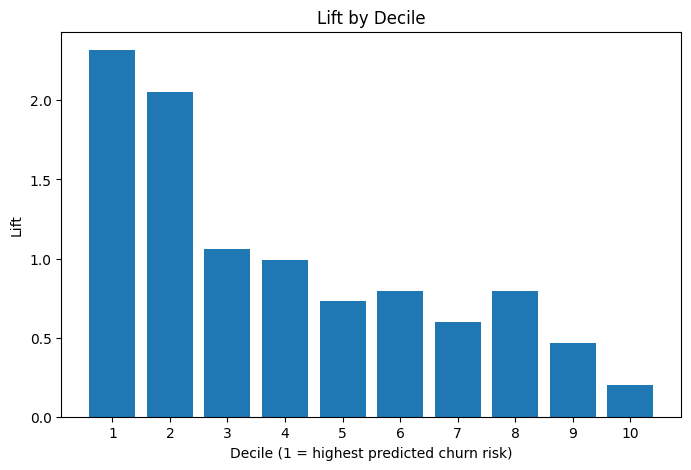

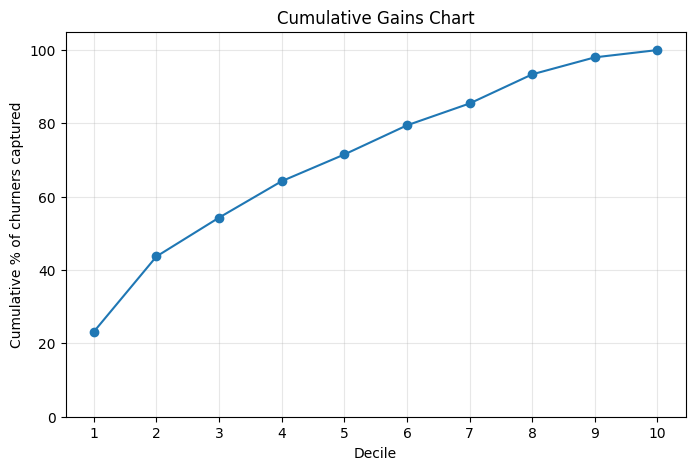

In [ ]:

plt.figure(figsize=(8,5))
plt.bar(decile_table['decile'], decile_table['lift'])
plt.xlabel('Decile (1 = highest predicted churn risk)')
plt.ylabel('Lift')
plt.title('Lift by Decile')
plt.xticks(decile_table['decile'])
plt.show()

plt.figure(figsize=(8,5))
plt.plot(decile_table['decile'], decile_table['cum_pct_churners'] * 100, marker='o')
plt.xlabel('Decile')
plt.ylabel('Cumulative % of churners captured')
plt.title('Cumulative Gains Chart')
plt.xticks(decile_table['decile'])
plt.ylim(0, 105)
plt.grid(True, alpha=0.3)
plt.show()



The first two deciles are clearly the most valuable. Decile 1 has the highest churn rate and the highest lift, and decile 2 is also much stronger than average. After that, the lift drops off a lot.

That tells me the model is useful for ranking customers by risk, even if plain accuracy does not tell the full story.


## 2c. Business value of targeting the top 20%

In [ ]:

top20 = scored[scored['decile'].isin([1,2])]

pct_churners_captured_top20 = top20['churned'].sum() / total_churners
random_capture_rate = 0.20

print("Top 20% churners captured:", round(pct_churners_captured_top20, 4))
print("Random 20% expected capture:", round(random_capture_rate, 4))


Top 20% churners captured: 0.4371
Random 20% expected capture: 0.2



If Pinnacle contacts the top 20% of predicted churners, it reaches about 43.7% of all actual churners. If the company picked a random 20%, it would only expect to reach about 20% of churners.

So the model-targeted approach is much better. In plain language, Pinnacle can spend the same marketing budget but focus it on the customers who are actually more likely to leave.


## 2d. Cost-benefit analysis

In [ ]:

contact_n = int(len(scored) * 0.20)
campaign_cost = contact_n * 50

expected_churners_top20 = top20['churned'].sum()
expected_saves_top20 = expected_churners_top20 * 0.30
expected_revenue_top20 = expected_saves_top20 * 1200
net_value_top20 = expected_revenue_top20 - campaign_cost

expected_churners_random = total_churners * 0.20
expected_saves_random = expected_churners_random * 0.30
expected_revenue_random = expected_saves_random * 1200
net_value_random = expected_revenue_random - campaign_cost

cost_benefit = pd.DataFrame({
    'Approach': ['Model-targeted top 20%', 'Random 20%'],
    'Customers Contacted': [contact_n, contact_n],
    'Campaign Cost': [campaign_cost, campaign_cost],
    'Expected Churners Contacted': [expected_churners_top20, expected_churners_random],
    'Expected Saves': [expected_saves_top20, expected_saves_random],
    'Expected Revenue from Saves': [expected_revenue_top20, expected_revenue_random],
    'Net Expected Value': [net_value_top20, net_value_random]
})

cost_benefit.round(2)


,Approach,Customers Contacted,Campaign Cost,Expected Churners Contacted,Expected Saves,Expected Revenue from Saves,Net Expected Value
0,Model-targeted top 20%,400,20000,66.000,19.800,"23,760.000","3,760.000"
1,Random 20%,400,20000,30.200,9.060,"10,872.000","-9,128.000"



The model-targeted campaign creates a positive expected value of about CAD 3,760, while a random campaign would lose about CAD 9,128.

Because of that, I would say the VP should proceed with the model-targeted campaign. The expected return is positive, and it is much better than using the same budget randomly.


# Part 3 - Customer Segmentation

## 3a. PCA

In [ ]:

numeric_features = customers.select_dtypes(include=[np.number]).drop(columns=['churned'])
scaler = StandardScaler()
scaled_customers = scaler.fit_transform(numeric_features)

pca = PCA()
pca_data = pca.fit_transform(scaled_customers)

cum_var = np.cumsum(pca.explained_variance_ratio_)
num_components_70 = np.argmax(cum_var >= 0.70) + 1

print("Number of components needed for at least 70% variance:", num_components_70)

loadings = pd.DataFrame(
    pca.components_.T[:, :2],
    index=numeric_features.columns,
    columns=['PC1','PC2']
)

print("\nTop absolute loadings for PC1")
display(loadings.reindex(loadings['PC1'].abs().sort_values(ascending=False).index).head(10))

print("\nTop absolute loadings for PC2")
display(loadings.reindex(loadings['PC2'].abs().sort_values(ascending=False).index).head(10))


Number of components needed for at least 70% variance: 6

Top absolute loadings for PC1


,PC1,PC2
total_spent_12mo,0.390,0.079
spend_apparel,0.369,0.101
spend_hiking,0.363,0.077
spend_camping,0.359,0.041
spend_accessories,0.352,0.091
income,0.321,0.011
num_purchases_12mo,0.275,-0.053
avg_order_value,0.256,0.129
age,0.249,-0.243
pct_online,-0.112,0.677



Top absolute loadings for PC2


,PC1,PC2
pct_online,-0.112,0.677
distance_to_store,-0.036,0.638
age,0.249,-0.243
avg_order_value,0.256,0.129
household_size,0.069,-0.116
spend_apparel,0.369,0.101
spend_accessories,0.352,0.091
total_spent_12mo,0.390,0.079
spend_hiking,0.363,0.077
days_since_last_purchase,-0.000,0.072



It takes 6 principal components to capture at least 70% of the total variance.

My interpretation of the first two PCs is:

- PC1 mostly represents overall spending and customer value. It loads heavily on total spending, category spending, income, number of purchases, and average order value.
- PC2 looks more like a channel/location dimension. It loads strongly on percent online and distance to store, so it seems to separate digital-oriented shoppers from store-nearby shoppers.

That gives a pretty intuitive business meaning to the PCA output.


## 3b. K-means clustering for k = 3, 4, and 5

In [ ]:

pca_for_clustering = pca_data[:, :num_components_70]

cluster_eval = []
for k in [3,4,5]:
    km = KMeans(n_clusters=k, n_init=25, random_state=42)
    labels = km.fit_predict(pca_for_clustering)
    cluster_eval.append({
        'k': k,
        'total_within_cluster_ss': km.inertia_,
        'avg_silhouette_score': silhouette_score(pca_for_clustering, labels)
    })

cluster_eval = pd.DataFrame(cluster_eval)
cluster_eval.round(3)


,k,total_within_cluster_ss,avg_silhouette_score
0,3,"13,092.730",0.223
1,4,"12,055.156",0.189
2,5,"11,196.645",0.174


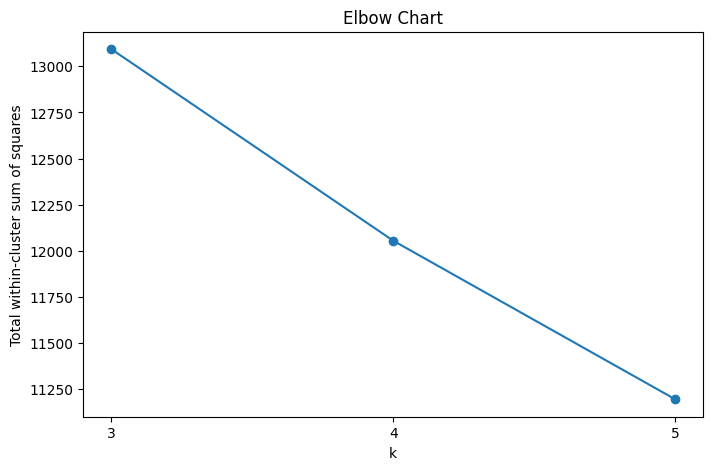

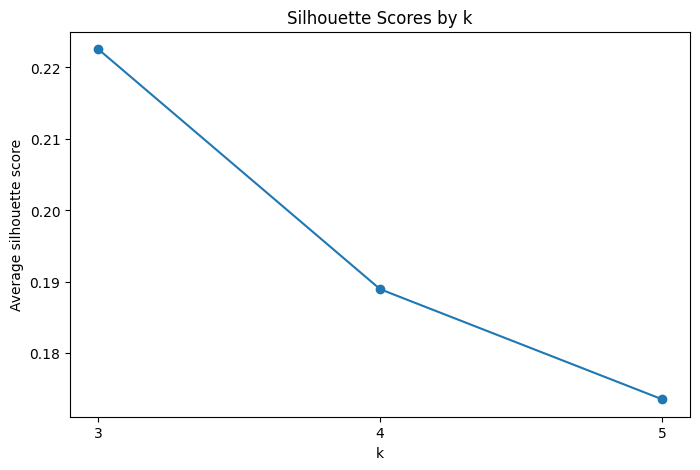

In [ ]:

plt.figure(figsize=(8,5))
plt.plot(cluster_eval['k'], cluster_eval['total_within_cluster_ss'], marker='o')
plt.xlabel('k')
plt.ylabel('Total within-cluster sum of squares')
plt.title('Elbow Chart')
plt.xticks(cluster_eval['k'])
plt.show()

plt.figure(figsize=(8,5))
plt.plot(cluster_eval['k'], cluster_eval['avg_silhouette_score'], marker='o')
plt.xlabel('k')
plt.ylabel('Average silhouette score')
plt.title('Silhouette Scores by k')
plt.xticks(cluster_eval['k'])
plt.show()



I would choose k = 3.

The elbow chart does improve as k increases, but that always happens when you add more clusters. The more important point is that k = 3 gives the highest silhouette score out of the three options, which means the clusters are the cleanest and most separated at that level.


## 3c. Profile the chosen clusters

In [ ]:

kmeans_final = KMeans(n_clusters=3, n_init=25, random_state=42)
customers['cluster'] = kmeans_final.fit_predict(pca_for_clustering)

cluster_profile = customers.groupby('cluster').agg(
    size=('customer_id','count'),
    mean_age=('age','mean'),
    mean_income=('income','mean'),
    mean_household_size=('household_size','mean'),
    mean_total_spent=('total_spent_12mo','mean'),
    mean_pct_online=('pct_online','mean'),
    mean_spend_camping=('spend_camping','mean'),
    mean_spend_hiking=('spend_hiking','mean'),
    mean_spend_apparel=('spend_apparel','mean'),
    mean_spend_accessories=('spend_accessories','mean')
).round(2)

top_category = customers.groupby('cluster')[[
    'spend_camping','spend_hiking','spend_apparel','spend_accessories'
]].mean().idxmax(axis=1)

cluster_profile['top_category'] = top_category
cluster_profile


,size,mean_age,mean_income,mean_household_size,mean_total_spent,mean_pct_online,mean_spend_camping,mean_spend_hiking,mean_spend_apparel,mean_spend_accessories,top_category
cluster,,,,,,,,,,,
0,908,30.360,"42,140.800",2.150,140.110,0.350,23.220,24.750,53.410,38.720,spend_apparel
1,439,48.260,"97,525.440",2.630,"1,748.680",0.270,435.610,805.480,324.510,183.080,spend_hiking
2,653,42.700,"70,294.570",3.560,635.650,0.290,267.740,151.870,147.310,68.730,spend_camping



My business names for the three clusters are:

- Cluster 0: Value-Driven Apparel Shoppers
- Cluster 1: High-Value Outdoor Enthusiasts
- Cluster 2: Family Camping Customers

Why I picked those names:
- Cluster 0 is younger, lower income, and lower spending overall, with apparel as the top category.
- Cluster 1 has the highest income and spending, with hiking as the top category.
- Cluster 2 is more middle-of-the-road financially, but camping is the strongest category, which fits a family/outdoor trip profile.


## 3d. Marketing recommendations by segment


1. Value-Driven Apparel Shoppers  
Channel: social media  
Product feature: apparel  
Offer type: percentage discount  

This group is younger and spends less overall, so a visible digital channel and a straightforward discount would probably work best.

2. High-Value Outdoor Enthusiasts  
Channel: mobile app push  
Product feature: hiking  
Offer type: early access to new products  

This segment already spends the most, so I would avoid training them to wait for discounts. Early access feels more premium and matches their high value.

3. Family Camping Customers  
Channel: email  
Product feature: camping  
Offer type: free shipping  

This group looks like a practical planning-oriented segment. Email works well for planned purchases, and free shipping can help remove friction on bigger camping orders.


# Part 4 - Executive Synthesis

## 4a. One-page executive memo


To: CEO, Pinnacle Outdoor Co.  
From: Student Analyst  
Subject: Recommended actions from pricing, churn, and segmentation analysis  

This analysis looked at three business questions: how to reduce losses on weak seasonal products, how to use retention offers more effectively in the loyalty program, and how to improve marketing by understanding customer segments.

First, I looked at week-6 sell-through rates for seasonal products. The lowest-performing items were mostly accessories, and many were relatively high-priced. The regression model also showed a negative relationship between price and units sold, which supports the idea that pricing is affecting demand. Based on this, I recommend immediate markdowns for the 10 worst-performing products instead of waiting until the end of the season. A markdown strategy of about 15% to 25%, depending on how weak the product is, is expected to generate more revenue than sending the remaining inventory straight to liquidation.

Second, I built a churn model for loyalty members and ranked customers by predicted churn risk. The top 20% of customers by predicted risk captured about 43.7% of all actual churners, compared with only 20% if Pinnacle contacted a random 20% of members. Using the campaign assumptions in the case, the model-targeted offer strategy produces an expected positive value of about CAD 3,760, while a random selection strategy would create an expected loss of about CAD 9,128. Based on that result, I recommend using the model to target the top-risk customers for the retention campaign.

Third, I ran customer segmentation and found that Pinnacle's customer base is not one single group. The data supports three main segments: younger value-driven apparel shoppers, high-value outdoor enthusiasts, and family camping customers. Because these groups differ in spending level, product interests, and shopping behavior, I recommend moving away from identical mass emails. Instead, Pinnacle should tailor channel, product focus, and offer type to each group.

Overall, these results suggest that Pinnacle can improve performance by acting more precisely. Markdowns should be used selectively for weak products, retention offers should go to the customers with the highest churn risk, and marketing should be tailored to clear customer segments rather than sent the same way to everyone.


## 4b. If only one recommendation can be implemented this quarter


If Pinnacle can only implement one recommendation this quarter, I would choose the model-targeted churn campaign.

The main reason is that this recommendation has the clearest and easiest-to-defend ROI. The expected net value is positive at about CAD 3,760, while the random alternative is clearly negative. That makes this the most direct business case in the assignment.

It also seems easier to implement than the other two options. A targeted retention campaign can be launched fairly quickly because the customer list already exists and the budget is clearly defined. The markdown strategy is also useful, but it may need more coordination across merchandising and inventory teams. The segmentation work is valuable too, but it is more of a medium-term marketing improvement than an immediate quarter-impact move.

So if the CEO wants one action with a clear payoff, limited complexity, and quick execution, the churn campaign is the best choice.
